In [3]:
#by Henry Schumacher
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#
import time
start_setup = time.process_time_ns()
print('---------------------------------------')
print(time.strftime("PLSmethods.ipynb started: %a, %d %b %Y %H:%M:%S", time.localtime()))
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#
import os
import sys
import json
import uuid
import h5py
import math
import xraydb
import plotly
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#
import numpy as np
import pandas as pd
# import pyxray as xy
import odrpack as odr
import seaborn as sb
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#
import matplotlib.pyplot as plt
from matplotlib import ticker
from matplotlib.gridspec import GridSpec
from scipy.signal import find_peaks
from scipy.optimize import curve_fit
from scipy.special import voigt_profile
from scipy.ndimage import median_filter
from pybaselines import Baseline
from getmac import get_mac_address as gma
from itertools import chain
from matplotlib.offsetbox import OffsetImage, AnnotationBbox, TextArea, VPacker
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#
from colors import load_colors
from functions_pixe import *
from polygauss import *
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#

from matplotlib import rc
# rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})
## for Palatino and other serif fonts use:
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times"],
    "text.usetex": True,
    "font.size": 8,
    "pgf.rcfonts": False
})


plt.rcParams.update({
    "pgf.texsystem": "pdflatex",
    "pgf.preamble": "\n".join([
          r'\usepackage{amsmath}',
     ]),
})

#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#
color_schemes = load_colors()


end_setup = time.process_time_ns()
elapsed_setup = (end_setup - start_setup)/1e6

print(f'INFO: SETUP COMPLETE ({elapsed_setup:.4f} ms)')
print('---------------------------------------')
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#

---------------------------------------
PLSmethods.ipynb started: Tue, 09 Jun 2026 15:19:18
INFO: SETUP COMPLETE (0.0000 ms)
---------------------------------------


In [4]:
def rmse(data:list, fit:list, length:int):
    '''
    Root-Mean-Square-Error
    '''
    data = np.array(data)
    fit = np.array(fit)
    return np.sqrt(np.sum((data-fit)**2)/length)

def rmse_gcv(data:list, fit:list, length:int):
    '''
    Root-Mean-Square-Error gap-cross-validation
    compare: Eilers_2003
    '''

In [5]:
def both_chi_squared(bin_data:list, fit_data:list, params:list):
    bin_data = np.array(bin_data)
    fit_data = np.array(fit_data)
    dof = len(bin_data) - len(params)
    var = np.sqrt(np.var(bin_data))
    return sum(((fit_data-bin_data)/ var)**2), sum(((fit_data-bin_data)/ var)**2) / dof

def goodness_of_fit(bin_data:list, fit_data:list):
    bin_data = np.array(bin_data)
    fit_data = np.array(fit_data)
    
    rss = sum((bin_data - fit_data)**2)
    tss = sum((bin_data - np.average(bin_data))**2)
    return 1 - rss/tss

In [6]:
def arpls_baseline(bin_data:list, bins:list, lam:int = 1e2):
    bsl_fitter = Baseline(x_data=bins)
    
    baseline, params = bsl_fitter.arpls(bin_data, lam=lam, max_iter=400)
    subtracted = bin_data - baseline
    return baseline, subtracted

def aspls_baseline(bin_data:list, bins:list, lam:int = 1e2):
    bsl_fitter = Baseline(x_data=bins)
    
    baseline, params = bsl_fitter.aspls(bin_data, lam=lam, max_iter=400)
    subtracted = bin_data - baseline
    return baseline, subtracted

### Signal-to-Noise Ratio $SNR$

The Power-value of a signal (or the noise) is the mean of the signal (noise) squared so $P = N^{-1}\cdot\sum_{i=0}^{N} y_{i}^2$.

The $SNR$ is now just $SNR_{dB} = 10\log_{10}(\dfrac{P_{Signal}}{P_{Noise}})$.

Reversing this calculation gives the possibility to set a specific $SNR$ through: $P_{Noise} = \sqrt{\dfrac{P_{Signal}}{10^{(SNR_{dB}/10)}}}$.

In [185]:
def toy_model(N:int, snr:int, baseline_type:str):
    rng = np.random.default_rng()
    
    x = np.linspace(0,8191,8192)
    # GAUSS
    heights = rng.integers(low=100, high=5e4, size=N)
    widths = rng.integers(low=10, high=100, size=N)
    centers = rng.integers(low=100, high=8100, size=N)
    # print(heights, widths, centers)
    gauss_info = []
    for i in range(0,N):
        gauss_info.append(heights[i])
        gauss_info.append(centers[i])
        gauss_info.append(widths[i])
        
    peak_data = multi_gauss(gauss_info, x)
    P_signal = np.mean(peak_data**2)
    
    # BASELINE
    if (baseline_type == 'sine'):
        if (N > 5):
            sine_amp = rng.uniform(low=10000, high=2000*N)
        else:
            sine_amp = rng.uniform(low=10000, high=10000 + 2000*N)
        sine_freq = rng.uniform(low=0.00025, high=0.0006)
        sine_shift = rng.uniform(low=0, high=10000)
        bsl_param = [sine_amp, sine_freq, sine_shift]
        baseline = sine_amp*np.sin(sine_freq*x + sine_shift)
    elif (baseline_type == 'lin'):
        offset = rng.uniform(low=-1000, high=10000)
        steep = rng.uniform(low=-4, high=4)
        bsl_param = [offset,steep]
        baseline = offset + x*steep
    elif (baseline_type == 'exp'):
        # a*e^{bx+c}
        exp_a = rng.uniform(low=10, high=20*N)
        exp_b = rng.uniform(low=-1e-3, high=-1e-4)
        exp_c = rng.uniform(low=4, high=8)
        bsl_param = [exp_a, exp_b, exp_c]
        baseline = exp_a*np.exp(exp_b*x + exp_c)
    
       
    # NOISE
    P_noise = P_signal / (10**(snr/10))
    sigma_noise = np.sqrt(P_noise)
    noise = rng.normal(loc=0.0, scale=sigma_noise, size=8192)
    # print(noise)
    print(f'SNR: {snr:.3f}')
    
    
    plt.figure(figsize=(20,4), dpi=250)
    plt.plot(x, peak_data, zorder=3, color='black')
    plt.plot(x, peak_data + noise + baseline, zorder=2, color='firebrick')
    # plt.plot(x, peak_data + baseline + 10000)
    # plt.plot(x, baseline)
    plt.grid(axis='y')
    plt.show()
    
    toy_model_data = {
        "NumberOfPeaks": N,
        "SNR": snr,
        "GaussianPeaks": gauss_info,
        "Noise": noise,
        "BaselineType": baseline_type,
        "BaselineParameter": bsl_param,
        "Baseline": baseline        
    }
    return toy_model_data

In [186]:
def load_data(filename:str):
    data = read_json_formatted_file(filename)
    
    bin_data = np.array(data['RawData'][:-1])
    bins = np.arange(0,len(bin_data),1)
    bin_data_zerofixed = np.where(bin_data == 0, 1, bin_data)
    data_err = np.sqrt(bin_data_zerofixed)
    
    meas_name = filename.split('//')[3].split('.')[0]
    meas_folder = filename.split('//')[2]

SNR: 30.000


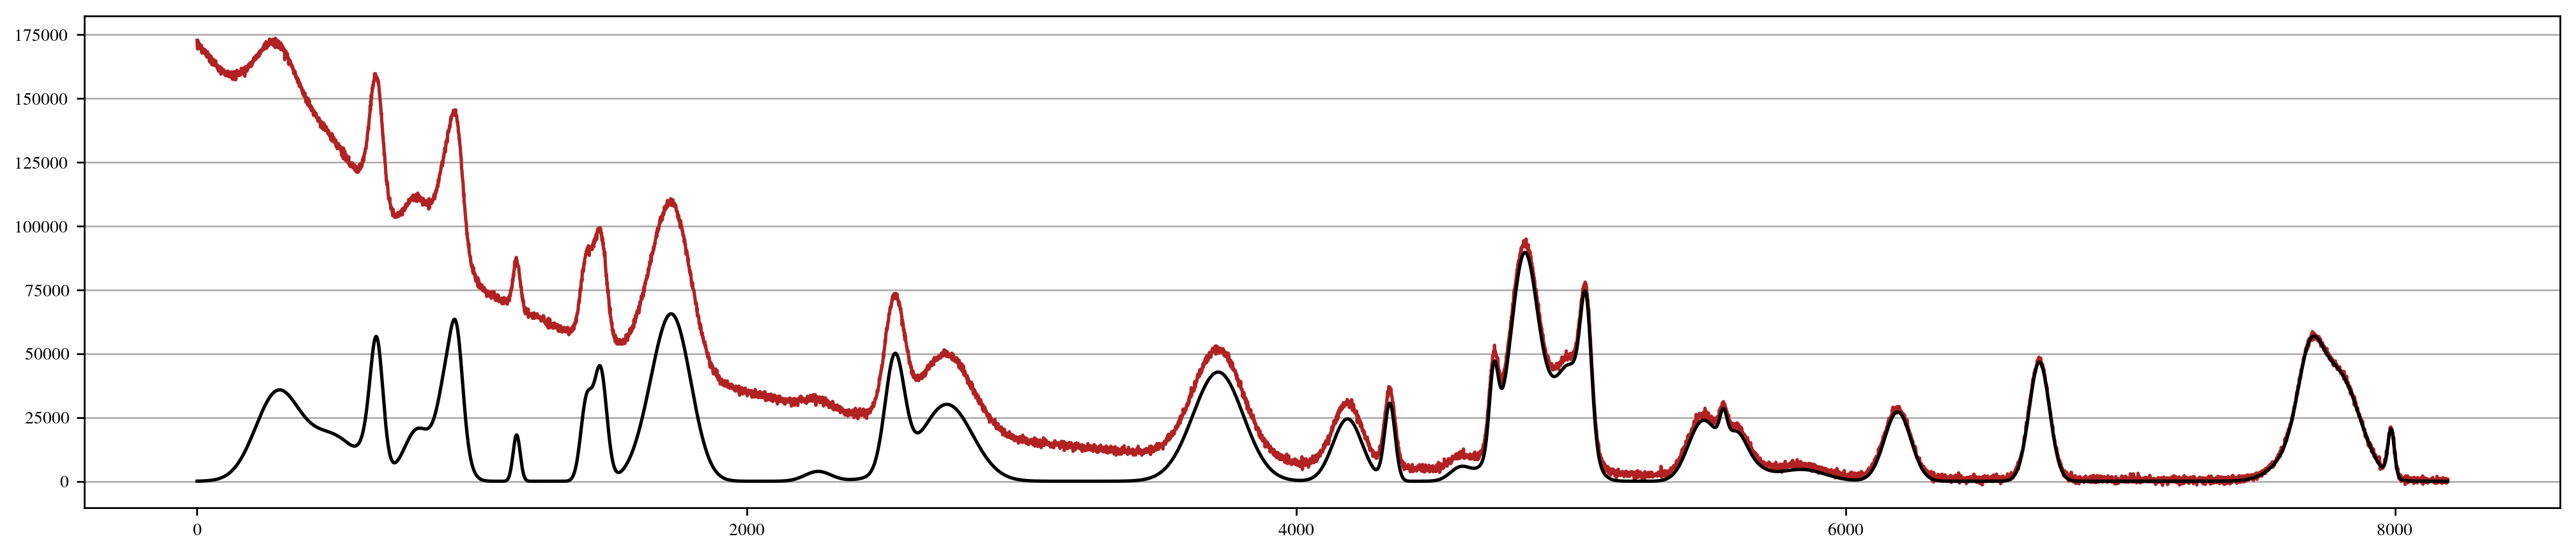

{'NumberOfPeaks': 40, 'SNR': 30, 'GaussianPeaks': [np.int64(30397), np.int64(4719), np.int64(16), np.int64(21305), np.int64(2726), np.int64(97), np.int64(20027), np.int64(5473), np.int64(50), np.int64(2332), np.int64(7815), np.int64(68), np.int64(12496), np.int64(5590), np.int64(73), np.int64(41515), np.int64(4844), np.int64(85), np.int64(15097), np.int64(7675), np.int64(87), np.int64(27613), np.int64(7689), np.int64(43), np.int64(3843), np.int64(2260), np.int64(48), np.int64(18499), np.int64(7985), np.int64(12), np.int64(16594), np.int64(641), np.int64(31), np.int64(1601), np.int64(2505), np.int64(81), np.int64(36982), np.int64(655), np.int64(22), np.int64(37273), np.int64(5004), np.int64(51), np.int64(23142), np.int64(947), np.int64(21), np.int64(24438), np.int64(4187), np.int64(53), np.int64(3115), np.int64(3647), np.int64(93), np.int64(45966), np.int64(921), np.int64(39), np.int64(4602), np.int64(5839), np.int64(86), np.int64(43313), np.int64(1468), np.int64(23), np.int64(40451), n

In [194]:
tmd = toy_model(N=40, snr=30, baseline_type='exp')

print(tmd)